# Double ML causal inference

### Импорты

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns

import doubleml as dml

from sklearn.base import ClassifierMixin
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict

import xgboost as xgb
import optuna

from optuna.integration import OptunaSearchCV
from optuna.distributions import IntDistribution, FloatDistribution

from tqdm.auto import tqdm

import warnings

alpha = 0.1
RANDOM_STATE = 123

sns.set_style("whitegrid")
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")
np.random.seed(RANDOM_STATE)

### Данные

In [2]:
df = pd.read_csv("../data/final_dataset.csv")
df_men = df[df["sex"] == 1]
df_women = df[df["sex"] == 2]

In [3]:
df_men

,heart,lungs,liver,kidneys,stomach,spine,diabetes,hypertension,joints,ENT_organs,...,invalid,mar_st,visit_doctor,work,alcohol,smoking,phys_active,is_health_good,is_health_very_good,diploma
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0
8,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
16,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0
26,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4586,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0
4587,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0
4589,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
4592,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0


In [4]:
df_women

,heart,lungs,liver,kidneys,stomach,spine,diabetes,hypertension,joints,ENT_organs,...,invalid,mar_st,visit_doctor,work,alcohol,smoking,phys_active,is_health_good,is_health_very_good,diploma
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4591,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
4593,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
4594,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
4596,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
treatment = "diploma"
controls = ["age", "type_area", "invalid"]

### Вспомогательные функции и сетки гиперпараметров

In [6]:
rf_distributions = {
    "n_estimators": IntDistribution(100, 500, step=50),
    "max_depth": IntDistribution(3, 12),
    "min_samples_leaf": IntDistribution(2, 20),
}

xgb_distributions = {
    "n_estimators": IntDistribution(100, 500, step=50),
    "max_depth": IntDistribution(3, 8),
    "learning_rate": FloatDistribution(0.01, 0.2, log=True),
}


class _ClassifierOptunaSearchCV(ClassifierMixin, OptunaSearchCV):
    pass


def _make_learner(model):
    if model == "LDA":
        return LinearDiscriminantAnalysis()
    if model == "RF":
        base = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
        return _ClassifierOptunaSearchCV(
            base,
            param_distributions=rf_distributions,
            n_trials=20,
            cv=3,
            random_state=RANDOM_STATE,
            verbose=0,
        )
    if model == "XGB":
        base = xgb.XGBClassifier(
            random_state=RANDOM_STATE,
            verbosity=0,
            eval_metric="logloss",
        )
        return _ClassifierOptunaSearchCV(
            base,
            param_distributions=xgb_distributions,
            n_trials=20,
            cv=3,
            random_state=RANDOM_STATE,
            verbose=0,
        )


def fit_irm(dml_data, model, score):
    score_internal = "ATTE" if score == "ATET" else "ATE"

    irm = dml.DoubleMLIRM(
        dml_data,
        ml_g=_make_learner(model),
        ml_m=_make_learner(model),
        ps_processor_config=dml.utils.PSProcessorConfig(clipping_threshold=0.03),
        n_folds=3,
        score=score_internal,
    )
    irm.fit(n_jobs_cv=-1)
    return irm


def print_all_models(dml_data, label=""):
    for model in ["LDA", "RF", "XGB"]:
        for score in ["ATE", "ATET"]:
            irm = fit_irm(dml_data, model, score)
            header = f"{label} | {model} | {score}".strip(" |")
            print(f"--- {header} ---")
            print(irm.summary)
            print(irm.confint(level=1 - alpha))
            print()

Прежде чем приступить непосредственно к расчету эффекта образования на вероятности различных болезней кратко сформулируем план действий:

- Протестируем гипотезы о значимости коэффициентов и оценим их методом `DoubleML`

На каждом этапе будем оценивать как ATE, так и ATET (ATET вспомогательно)

### Женщины и гипертония

In [7]:
outcome = "hypertension"

In [8]:
dml_data_women = dml.DoubleMLData(
    df_women, y_col=outcome, d_cols=treatment, x_cols=controls
)
dml_data_men = dml.DoubleMLData(
    df_men, y_col=outcome, d_cols=treatment, x_cols=controls
)

In [9]:
print_all_models(dml_data_women, label="Women + hypertension")

--- Women + hypertension | LDA | ATE ---
             coef   std err         t     P>|t|     2.5 %    97.5 %
diploma -0.038668  0.015616 -2.476195  0.013279 -0.069275 -0.008062
            5.0 %    95.0 %
diploma -0.064355 -0.012982

--- Women + hypertension | LDA | ATET ---
             coef   std err         t     P>|t|     2.5 %    97.5 %
diploma -0.029787  0.014674 -2.029924  0.042364 -0.058547 -0.001027
            5.0 %   95.0 %
diploma -0.053923 -0.00565

--- Women + hypertension | RF | ATE ---
             coef   std err         t     P>|t|     2.5 %   97.5 %
diploma -0.040716  0.015463 -2.633163  0.008459 -0.071023 -0.01041
            5.0 %    95.0 %
diploma -0.066151 -0.015282

--- Women + hypertension | RF | ATET ---
             coef   std err         t     P>|t|    2.5 %    97.5 %
diploma -0.027216  0.014773 -1.842296  0.065432 -0.05617  0.001738
            5.0 %    95.0 %
diploma -0.051515 -0.002917

--- Women + hypertension | XGB | ATE ---
             coef   std err  

Как видим, все модели на уровне значимости $\alpha = 0.1$ показывают значимый отрицательный эффект образования на вероятность развития гипертонии

### Женщины и заболевания глаз

In [10]:
outcome = "eyes"

In [11]:
dml_data_women = dml.DoubleMLData(
    df_women, y_col=outcome, d_cols=treatment, x_cols=controls
)
dml_data_men = dml.DoubleMLData(
    df_men, y_col=outcome, d_cols=treatment, x_cols=controls
)

In [12]:
print_all_models(dml_data_women, label="Women + eyes")

--- Women + eyes | LDA | ATE ---
             coef   std err         t     P>|t|     2.5 %    97.5 %
diploma  0.015613  0.012974  1.203361  0.228837 -0.009816  0.041042
            5.0 %    95.0 %
diploma -0.005728  0.036954

--- Women + eyes | LDA | ATET ---
            coef   std err         t     P>|t|     2.5 %    97.5 %
diploma  0.01754  0.013101  1.338842  0.180622 -0.008137  0.043218
            5.0 %   95.0 %
diploma -0.004009  0.03909

--- Women + eyes | RF | ATE ---
            coef   std err         t     P>|t|     2.5 %    97.5 %
diploma  0.01812  0.012955  1.398721  0.161897 -0.007271  0.043511
            5.0 %    95.0 %
diploma -0.003189  0.039429

--- Women + eyes | RF | ATET ---
             coef   std err         t     P>|t|     2.5 %    97.5 %
diploma  0.021112  0.012833  1.645197  0.099929 -0.004039  0.046264
            5.0 %   95.0 %
diploma  0.000004  0.04222

--- Women + eyes | XGB | ATE ---
             coef   std err         t     P>|t|     2.5 %    97.5 %
dip

При влиянии наличия высшего образования на вероятность заболеваний глаз нет стат значимого эффекта (кроме ATET при использовании `RandomForest`)

### Женщины и аллергия

In [13]:
outcome = "allergy"

In [14]:
dml_data_women = dml.DoubleMLData(
    df_women, y_col=outcome, d_cols=treatment, x_cols=controls
)
dml_data_men = dml.DoubleMLData(
    df_men, y_col=outcome, d_cols=treatment, x_cols=controls
)

In [15]:
print_all_models(dml_data_women, label="Women + allergy")

--- Women + allergy | LDA | ATE ---
             coef   std err         t     P>|t|     2.5 %    97.5 %
diploma  0.009047  0.011101  0.814974  0.415087 -0.012711  0.030806
            5.0 %    95.0 %
diploma -0.009213  0.027308

--- Women + allergy | LDA | ATET ---
             coef   std err         t   P>|t|     2.5 %    97.5 %
diploma  0.010441  0.011111  0.939644  0.3474 -0.011337  0.032219
            5.0 %    95.0 %
diploma -0.007836  0.028717

--- Women + allergy | RF | ATE ---
             coef  std err         t   P>|t|     2.5 %   97.5 %
diploma  0.011582  0.01153  1.004578  0.3151 -0.011015  0.03418
            5.0 %    95.0 %
diploma -0.007382  0.030547

--- Women + allergy | RF | ATET ---
             coef   std err         t     P>|t|     2.5 %   97.5 %
diploma  0.004943  0.011616  0.425488  0.670481 -0.017825  0.02771
            5.0 %   95.0 %
diploma -0.014165  0.02405

--- Women + allergy | XGB | ATE ---
             coef   std err         t     P>|t|     2.5 %    97.

Нет стат значимого эффекта $-$ все p-value высокие

### Мужчины и оценка состояния здоровья

In [16]:
outcome = "is_health_good"

In [17]:
dml_data_women = dml.DoubleMLData(
    df_women, y_col=outcome, d_cols=treatment, x_cols=controls
)
dml_data_men = dml.DoubleMLData(
    df_men, y_col=outcome, d_cols=treatment, x_cols=controls
)

In [18]:
print_all_models(dml_data_men, label="Men + is_health_good")

--- Men + is_health_good | LDA | ATE ---
            coef  std err         t     P>|t|     2.5 %    97.5 %
diploma  0.02204  0.02443  0.902147  0.366979 -0.025843  0.069923
            5.0 %    95.0 %
diploma -0.018145  0.062224

--- Men + is_health_good | LDA | ATET ---
             coef   std err         t     P>|t|     2.5 %    97.5 %
diploma  0.012682  0.023896  0.530723  0.595611 -0.034153  0.059517
            5.0 %    95.0 %
diploma -0.026623  0.051987

--- Men + is_health_good | RF | ATE ---
            coef   std err         t    P>|t|     2.5 %    97.5 %
diploma  0.00706  0.025287  0.279215  0.78008 -0.042501  0.056622
            5.0 %    95.0 %
diploma -0.034533  0.048654

--- Men + is_health_good | RF | ATET ---
             coef   std err         t     P>|t|   2.5 %    97.5 %
diploma  0.007724  0.024145  0.319888  0.749053 -0.0396  0.055048
            5.0 %   95.0 %
diploma -0.031992  0.04744

--- Men + is_health_good | XGB | ATE ---
            coef   std err         t 

Снова нет стат значимого эффекта

### Другие интересные наблюдения

Теперь будем оценивать сразу набор болезней из перечня

In [ ]:
diseases = [
    "heart",
    "lungs",
    "liver",
    "kidneys",
    "stomach",
    "spine",
    "diabetes",
    "hypertension",
    "joints",
    "ENT_organs",
    "neurology",
    "eyes",
    "allergy",
    "veins",
    "is_health_good",
]

results = []

for outcome in tqdm(diseases):
    dml_data_w = dml.DoubleMLData(
        df_women, y_col=outcome, d_cols=treatment, x_cols=controls
    )
    dml_data_m = dml.DoubleMLData(
        df_men, y_col=outcome, d_cols=treatment, x_cols=controls
    )

    for gender, dml_data in [("Women", dml_data_w), ("Men", dml_data_m)]:
        for score in ["ATE", "ATET"]:
            irm = fit_irm(dml_data, "RF", score)
            p_val = irm.pval.item()
            ci = irm.confint(level=1 - alpha)
            results.append({
                "outcome": outcome,
                "gender": gender,
                "model": "RF",
                "score": score,
                "coef": irm.coef.item(),
                "se": irm.se.item(),
                "p_val": p_val,
                "ci_low": ci.iloc[0, 0],
                "ci_high": ci.iloc[0, 1],
                "significant": p_val <= alpha,
            })

results_df = pd.DataFrame(results)

In [ ]:
sig = results_df[results_df["significant"]].copy()

for (gender, outcome), grp in sig.groupby(["gender", "outcome"], sort=False):
    print(f"{gender} - {outcome}:")
    for _, r in grp.iterrows():
        print(
            f"  {r['model']:3s} | {r['score']:4s} | "
            f"coef={round(r['coef'], 4)}  "
            f"p_val={round(r['p_val'], 4)}  "
            f"CI=[{round(r['ci_low'], 4)}, {round(r['ci_high'], 4)}]"
        )
    print()

In [ ]:
for sc in ["ATE", "ATET"]:
    fig, ax = plt.subplots(figsize=(9, 14))

    sub = results_df[
        (results_df["model"] == "RF") & (results_df["score"] == sc)
    ].reset_index(drop=True)

    for i, r in sub.iterrows():
        if r["significant"]:
            color = "#e74c3c"
        elif r["gender"] == "Women":
            color = "#3498db"
        else:
            color = "#2ecc71"

        ax.errorbar(
            r["coef"],
            i,
            xerr=[[r["coef"] - r["ci_low"]], [r["ci_high"] - r["coef"]]],
            fmt="o",
            color=color,
            capsize=3,
            capthick=1.2,
            linewidth=1.2,
            markersize=5,
        )

    ax.axvline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.set_yticks(np.arange(len(sub)))
    ax.set_yticklabels(
        [f"{r['outcome']}  ({r['gender']})" for _, r in sub.iterrows()],
        fontsize=8,
    )
    ax.set_xlabel(f"{sc} of Diploma", fontsize=11)
    ax.grid(axis="x", alpha=0.3, linestyle=":")

    sig_patch = mpatches.Patch(color="#e74c3c", label=f"Significant (p_val ≤ {alpha})")
    w_patch = mpatches.Patch(color="#3498db", label="Women - not significant")
    m_patch = mpatches.Patch(color="#2ecc71", label="Men - not significant")
    ax.legend(handles=[sig_patch, w_patch, m_patch], fontsize=9, loc="best")

    ax.set_title(
        f"Forest Plot - {sc}: Effect of Higher Education on Health Outcomes\n"
        f"(Double ML IRM, Random Forest, 90% CI)",
        fontsize=12,
    )

    plt.tight_layout()
    plt.savefig(f"../assets/dml_forest_plot_{sc.lower()}.png")
    plt.show()

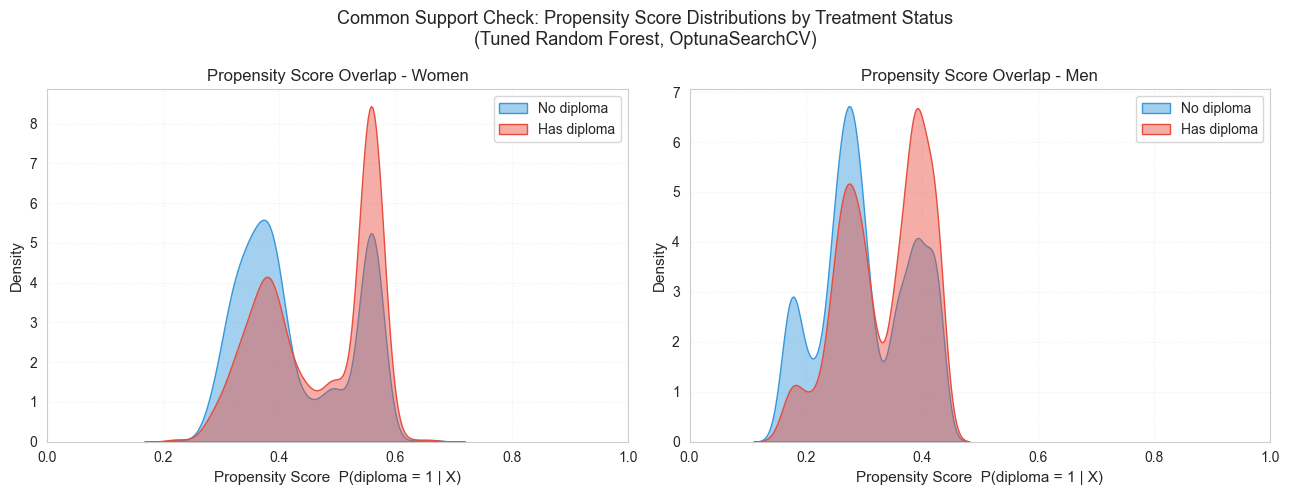

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (df_g, gender) in zip(axes, [(df_women, "Women"), (df_men, "Men")]):
    X = df_g[controls].values
    d = df_g[treatment].values.astype(int)
    clf = _make_learner("RF")
    ps = cross_val_predict(clf, X, d, cv=3, method="predict_proba")[:, 1]

    sns.kdeplot(
        ps[d == 0],
        ax=ax,
        label="No diploma",
        fill=True,
        alpha=0.45,
        color="#3498db",
        bw_adjust=0.8,
    )
    sns.kdeplot(
        ps[d == 1],
        ax=ax,
        label="Has diploma",
        fill=True,
        alpha=0.45,
        color="#e74c3c",
        bw_adjust=0.8,
    )

    ax.set_xlim(0, 1)
    ax.set_xlabel("Propensity Score  P(diploma = 1 | X)", fontsize=11)
    ax.set_ylabel("Density", fontsize=11)
    ax.set_title(f"Propensity Score Overlap - {gender}", fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3, linestyle=":")

plt.suptitle(
    "Common Support Check: Propensity Score Distributions by Treatment Status\n"
    "(Tuned Random Forest, OptunaSearchCV)",
    fontsize=13,
)
plt.tight_layout()
plt.savefig("../assets/dml_propensity_score.png")


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=True)

for ax, sc in zip(axes, ["ATE", "ATET"]):
    sub = results_df[(results_df["model"] == "RF") & (results_df["score"] == sc)]

    for _, r in sub.iterrows():
        coef = r["coef"]
        neg_log_p = -np.log10(r["p_val"])
        marker = "o" if r["gender"] == "Women" else "s"

        if not r["significant"]:
            color, zorder, alpha_pt = "#aab0b5", 1, 0.6
        elif coef > 0:
            color, zorder, alpha_pt = "#e74c3c", 3, 0.9
        else:
            color, zorder, alpha_pt = "#3498db", 3, 0.9

        ax.scatter(
            coef,
            neg_log_p,
            color=color,
            marker=marker,
            s=65,
            zorder=zorder,
            alpha=alpha_pt,
            edgecolors="white",
            linewidths=0.4,
        )

        if r["significant"]:
            ax.annotate(
                f"{r['outcome']} ({r['gender'][0]})",
                (coef, neg_log_p),
                fontsize=7.5,
                xytext=(5, 3),
                textcoords="offset points",
            )

    ax.axhline(
        -np.log10(alpha),
        color="dimgray",
        linestyle="--",
        linewidth=1,
    )
    ax.axvline(0, color="dimgray", linestyle=":", linewidth=0.8, alpha=0.5)

    ax.set_xlabel(f"{sc} of Diploma", fontsize=11)
    ax.set_ylabel(r"$-\log_{10}$(p-value)", fontsize=11)
    ax.set_title(f"Random Forest - {sc}", fontsize=12)
    ax.grid(alpha=0.3, linestyle=":")

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="#e74c3c",
        markersize=8,
        label="Significant - positive (Women)",
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        markerfacecolor="#e74c3c",
        markersize=8,
        label="Significant - positive (Men)",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="#3498db",
        markersize=8,
        label="Significant - negative (Women)",
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        markerfacecolor="#3498db",
        markersize=8,
        label="Significant - negative (Men)",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="#aab0b5",
        markersize=8,
        label="Not significant (Women)",
    ),
    Line2D(
        [0],
        [0],
        marker="s",
        color="w",
        markerfacecolor="#aab0b5",
        markersize=8,
        label="Not significant (Men)",
    ),
    Line2D(
        [0],
        [0],
        linestyle="--",
        color="dimgray",
        label=f"Significance threshold (p_val = {alpha})",
    ),
]
fig.legend(
    handles=legend_handles,
    fontsize=8,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.02),
)

fig.suptitle(
    "Volcano Plot: Effect of Higher Education on Health Outcomes\n"
    "(Double ML IRM, Random Forest)",
    fontsize=12,
    y=1.10,
)

plt.tight_layout()
plt.savefig("../assets/dml_volcano_plot.png")